# Projekt nr DWA na WK
By:
OK
WK
WK

(znowu razem)

Oskar Kiliańczyk 151863, Weronika Koga 151574, Wojciech Kot 151879

Tym razem było więcej męczenia się z tym, to jest trochę "posprzątany" notatnik, bo było gorzej. No ale zapraszamy na kolejną przejażdżkę, tym razem skróconą, tak - aby oszczędzić naszego zażenowania i może czasu kazdemu, kto to czyta.

In [1]:
# O nie! to doinstalowywanie rzeczy do Colaba!
# Otóż to, ale spokojnie, te działają! (a to już lepiej niż notebooki na ZMIO)
# Wszystko co się tu dzieje, to automatyczne pobieranie filmików z youtube'a, bo jesteśmy zbyt leniwi załączać je do sesji colaba za każdym razem jak odpalimy notatnik,
# i wolimy odpalić komórkę która będzie mielić się przez 5 minut i zrobić w tym czasie herbatkę. :)

!pip install yt-dlp
# !yt-dlp -f bestvideo+bestaudio --merge-output-format mp4 -o "bilard_overhead1.%(ext)s" https://www.youtube.com/watch?v=9awGUjKVewk
# !yt-dlp -f bestvideo+bestaudio --merge-output-format mp4 -o "snooker_test.%(ext)s" https://www.youtube.com/watch?v=e4CQ6M1TCnQ
!pip install moviepy

# !yt-dlp -f bestvideo+bestaudio --merge-output-format mp4 -o "snooker_test2.%(ext)s" https://www.youtube.com/watch?v=_H7ipblfNzs

!yt-dlp -f bestvideo+bestaudio --download-sections "*00:02:01-00:04:49" --merge-output-format mp4 -o "snooker_test1.%(ext)s" https://www.youtube.com/watch?v=e4CQ6M1TCnQ
!yt-dlp -f bestvideo+bestaudio --download-sections "*00:05:05-00:07:35" --merge-output-format mp4 -o "snooker_test2.%(ext)s" https://www.youtube.com/watch?v=e4CQ6M1TCnQ

!yt-dlp -f bestvideo+bestaudio --merge-output-format mp4 -o "snooker_test3.%(ext)s" https://www.youtube.com/watch?v=_H7ipblfNzs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.7 MB/s eta 0:00:00
[youtube] Extracting URL: https://www.youtube.com/watch?v=e4CQ6M1TCnQ
[youtube] e4CQ6M1TCnQ: Downloading webpage
[youtube] e4CQ6M1TCnQ: Downloading tv client config
[youtube] e4CQ6M1TCnQ: Downloading player 59b252b9-main
[youtube] e4CQ6M1TCnQ: Downloading tv player API JSON
[youtube] e4CQ6M1TCnQ: Downloading ios player API JSON
[youtube] e4CQ6M1TCnQ: Downloading m3u8 information
[info] e4CQ6M1TCnQ: Downloading 1 format(s): 616+251
[info] e4CQ6M1TCnQ: Downloading 1 time ranges: 121.0-289.0
[download] Destination: snooker_test1.mp4
[hls @ 0x58e9a4669480] Skip ('#EXT-X-VERSION:6')
[hls @ 0x58e9a4669480] Opening 'https://rr3---sn-5uaeznel.googlevideo.com/videoplayback/id/7b8090e8cd530a74/itag/616/source/youtube/expire/1748095496/ei/qH0xaNqxBOaGkucPgNHa8QE/ip/35.243.139.152/requiressl/yes/ratebypass/yes/pfa/1/wft/1/sgovp/clen%3D5587211

In [2]:
# To *Było* docinanie, aż nie wykminiliśmy że zamiast pobierać 1h filmu z youtube, można pobrać po prostu jego wycinki już tam wyżej...

# from moviepy.editor import VideoFileClip
# import os

# # Ścieżka do oryginalnego filmu
# input_path = "snooker_test.mp4"

# # Lista par (start, end) w sekundach
# time_segments = [
#     (2*60 + 1, 4*60 + 49),   # 2:01 - 4:49
#     (5*60 + 5, 7*60 + 35),   # 5:05 - 7:35
# ]

# # Pętla wycinająca i zapisująca podsegmenty
# for i, (start_sec, end_sec) in enumerate(time_segments, start=1):
#     output_path = f"snooker{i}.mp4"
#     if os.path.exists(output_path):
#         print(f"Plik {output_path} już istnieje, pomijam.")
#         continue

#     clip = VideoFileClip(input_path)
#     clip_sub = clip.subclip(start_sec, end_sec)
#     print(f"Tworzę {output_path} z {start_sec}s do {end_sec}s...")
#     clip_sub.write_videofile(output_path, codec="libx264")

# print("Wszystkie fragmenty gotowe.")


Tu zaczyna się wreszcie "mięsko".
A przynajmniej cokolwiek chociaż związanego z widzeniem komputerowym, a więc naszym tytułowym WK. Ale nie WK, ani WK, tylko tym **WK**. Mam nadzieję że będzie OK. W sensie OK jest, ale że będzie OK w sensie dobrze.

Wszyscy nadążają? - no to OK, to lecimy.

Klatka załadowana.


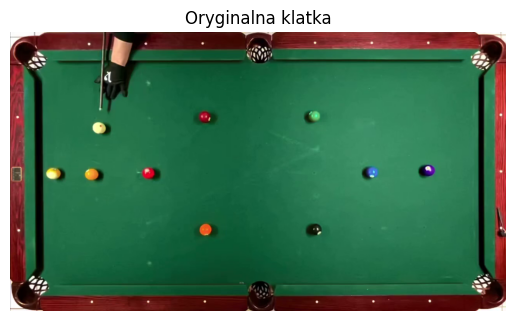

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img, title=''):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

video_path = 'snooker_test3.mp4'   # <- to Tu się zmienia ścieżkę, żeby zmienić wideo. Tak, bo pobieramy bazowo już 3...
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("Nie udało się wczytać klatki wideo.")
else:
    print("Klatka załadowana.")
    show_image(frame, 'Oryginalna klatka')

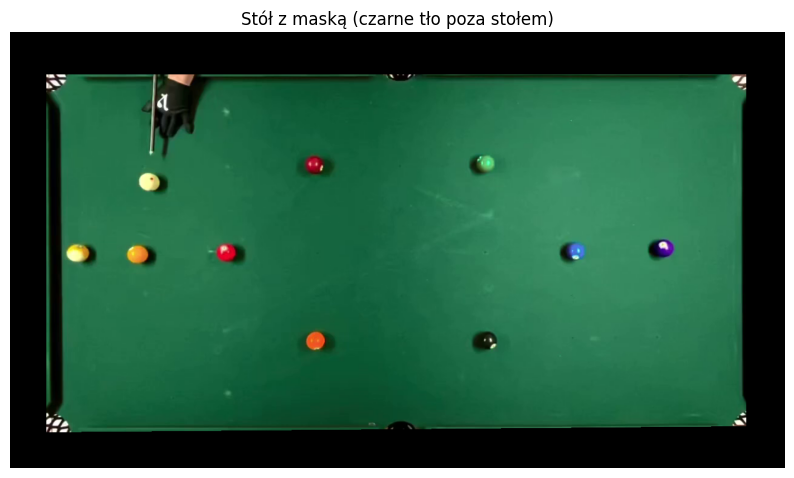

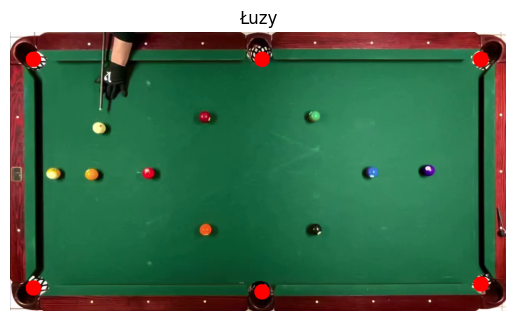

In [4]:
# punkty krawędzi stołu (snooker1,2)
# HA, HB = (550, 248), (1372, 248)
# HE, HF = (468, 534), (1442, 540)
# HC, HD = (398, 940), (1510, 940)

# punkty krawędzi stołu (snooker3)
HA, HB = (60, 660), (60, 70)
HE, HF = (650, 670), (650, 70)
HC, HD = (1215, 650), (1215, 70)
HOLES = HA, HB, HC, HD, HE, HF   # <- ważne! upewnij się że masz dobry stół zaznaczony ;)

# Przykładowa funkcja tworząca maskę stołu
def create_table_mask(img_shape):
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    # Ustawiamy wielokąt stołu - 4 narożniki (ustal według swojego stołu)
    table_corners = np.array([HA, HC, HD, HB])
    cv2.fillConvexPoly(mask, table_corners, 1)  # wypełnij maskę wartością 1 (białe)
    return mask

mask = create_table_mask(frame.shape)

# Pokaż obraz oryginalny * maska (maskę trzeba rozszerzyć do 3 kanałów)
masked_img = frame * mask[:, :, np.newaxis]

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
plt.title("Stół z maską (czarne tło poza stołem)")
plt.axis('off')
plt.show()

def draw_holes(img):
    for hole in HOLES:
        cv2.circle(img, hole, 20, (0, 0, 255), thickness=-1)

frame_with_holes = frame.copy()
draw_holes(frame_with_holes)

plt.imshow(cv2.cvtColor(frame_with_holes, cv2.COLOR_BGR2RGB))
# plt.title("Dziury na stole") # serio Oskar, to są Łuzy. Oraz bile, a nie kule. Masakra, jak z takimi pracować...
plt.title("Łuzy")
plt.axis('off')
plt.show()


Dobra, tu się dopiero coś zaczyna dziać, tamto to było ledwie początek.
Wreszcie zaczynamy cokolwiek wykrywać, chociaż zaczynamy - to akurat dobre słowo. Ale spokojnie, jeszcze będzie lepiej, to potem, nie wyprzedzajmy faktów.


Właściwie mamy to opisane ładnie komentarzami w kodzie, ale podobno opisy są też mile widziane, więc najwyżej pojawi się teraz pewna redundancja.
To podejście wykrywa kontury poprzez filt Sobela, a potem obrysowuje znalezione Bile za pomocą HoughCircles.
Oczywiście jest to skrajne uproszczenie, ale nad tym kodem chyba nie ma co się dużo rozwodzić, można zobaczyć że działa i iść dalej ;)

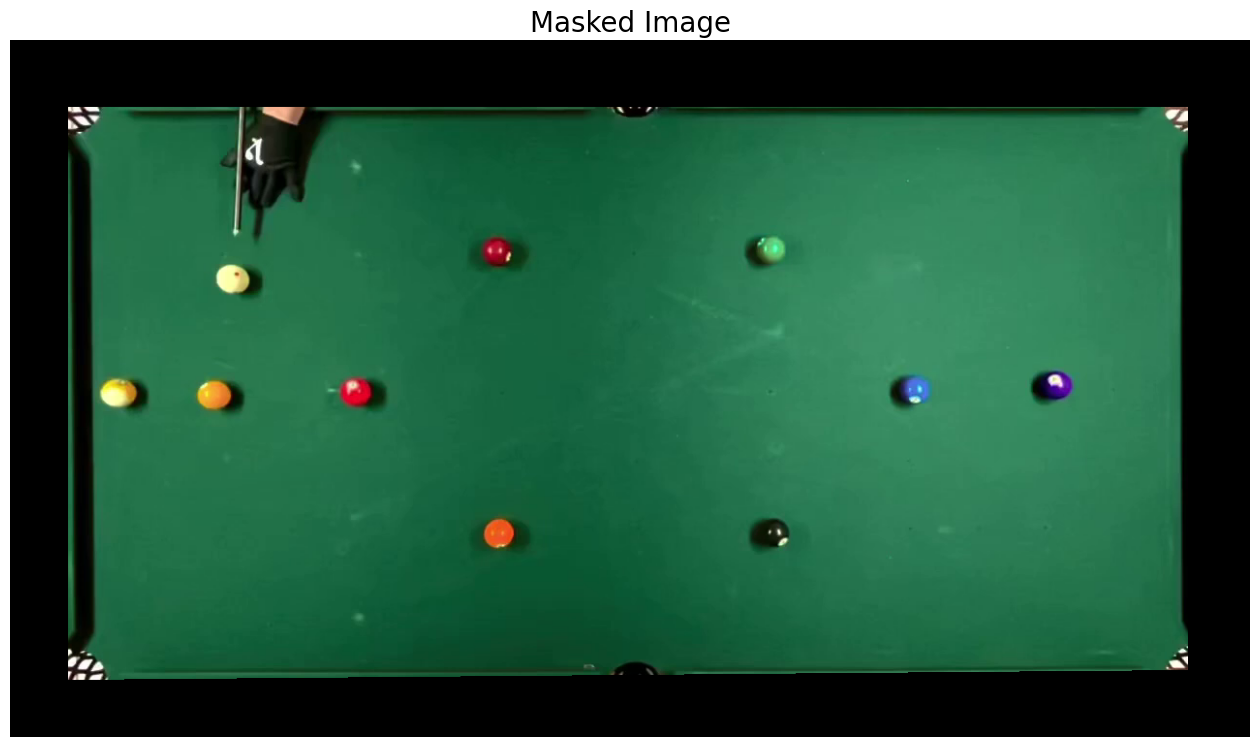

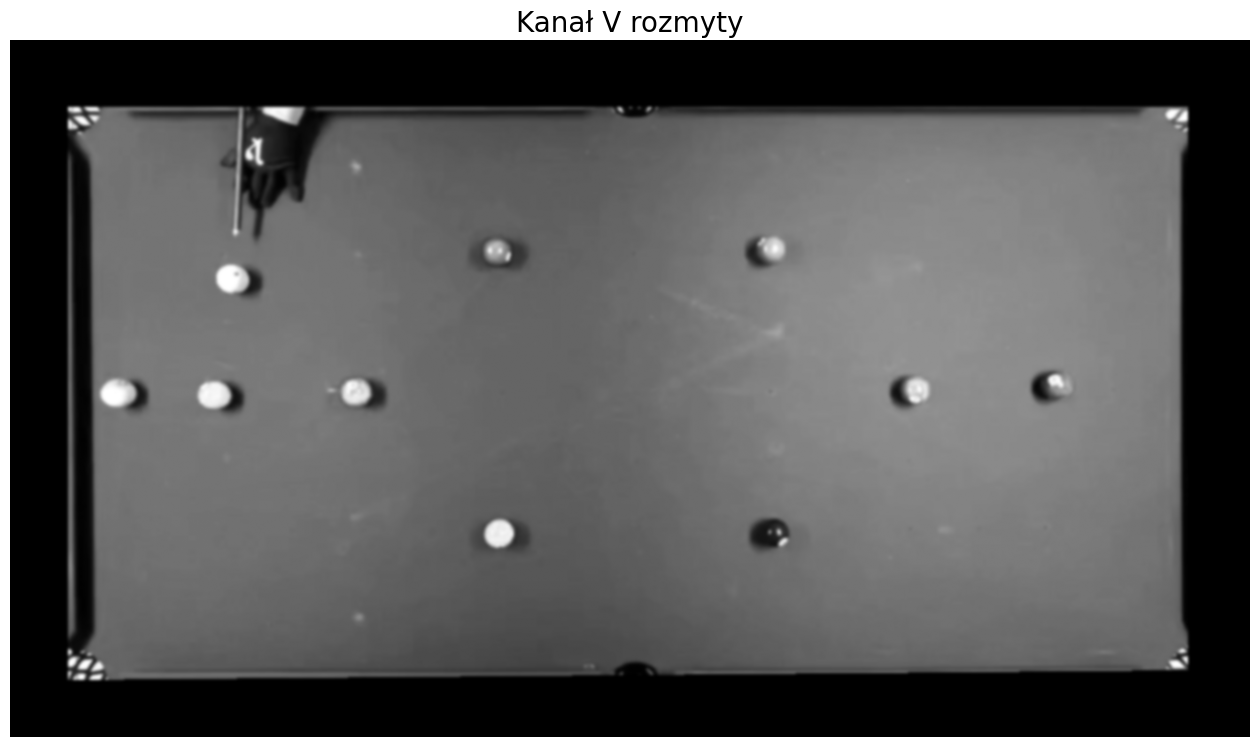

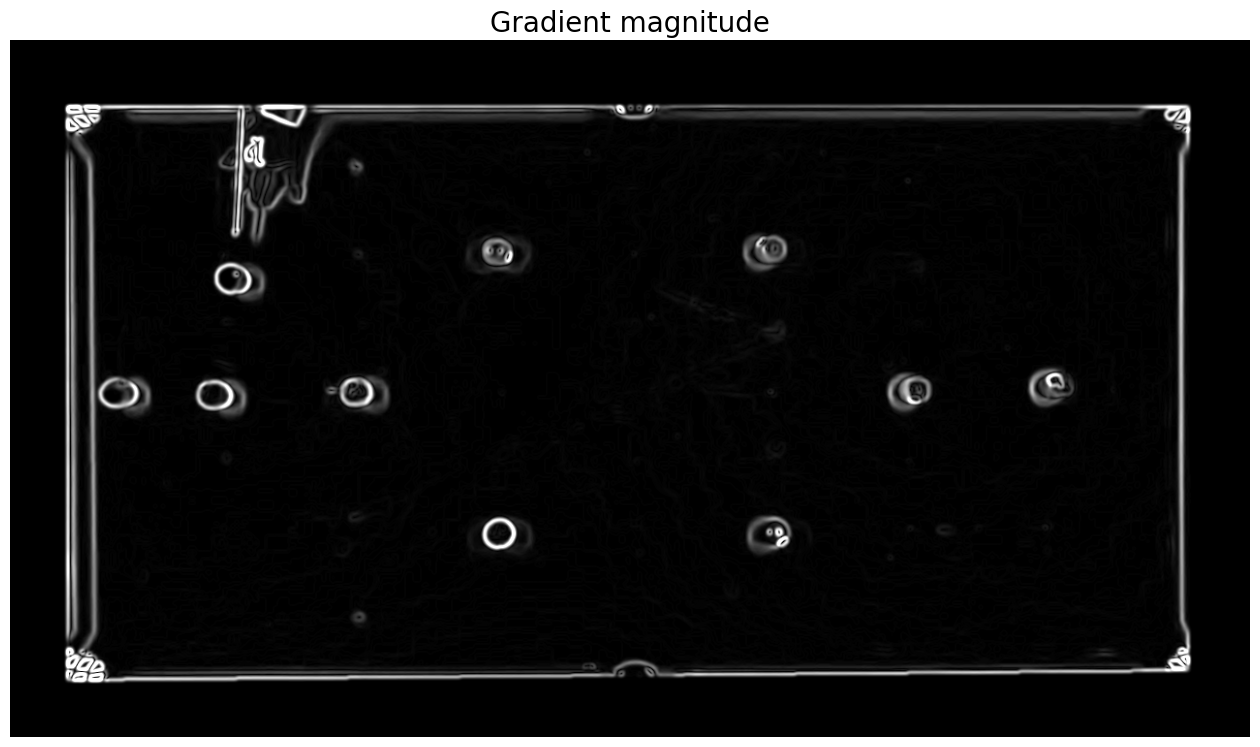

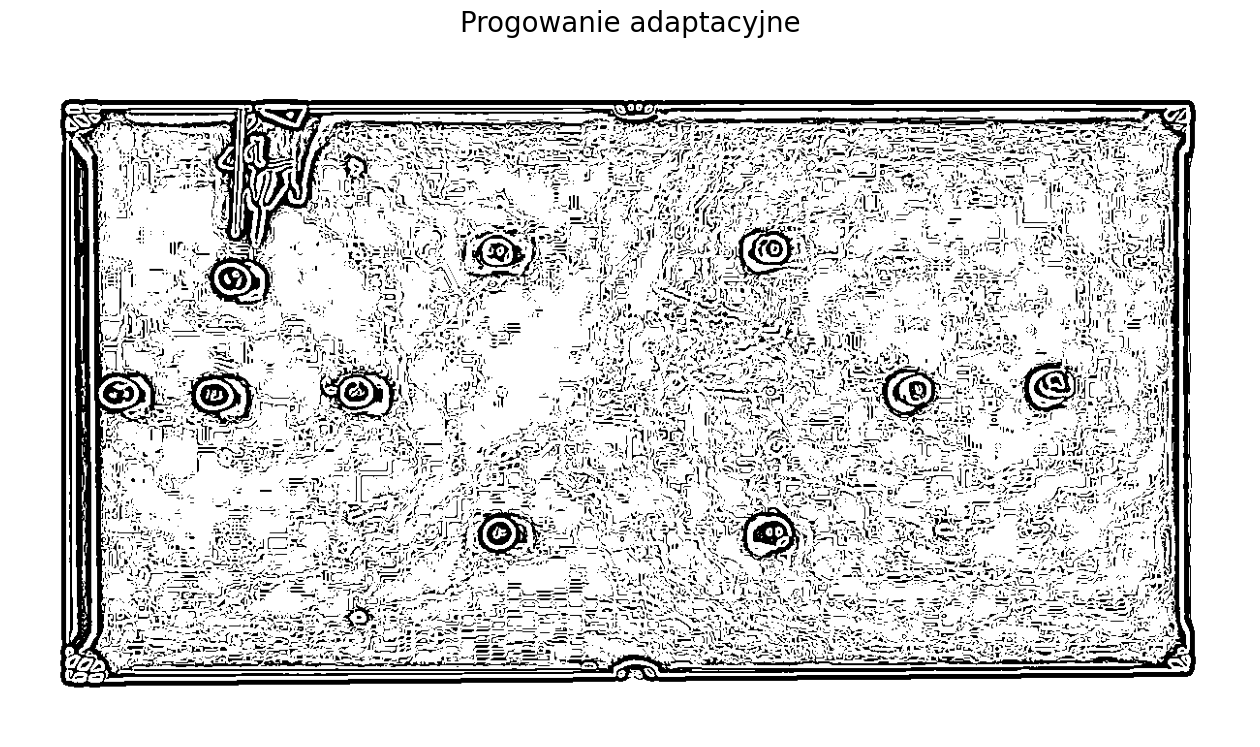

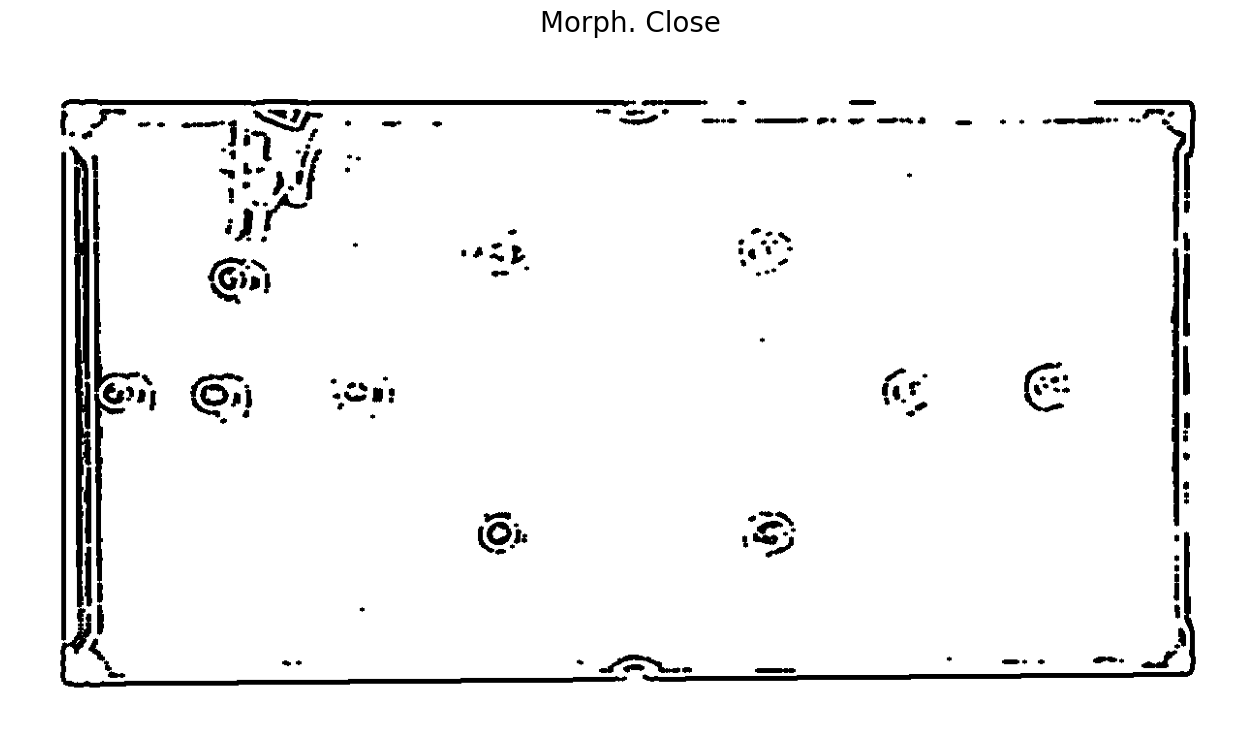

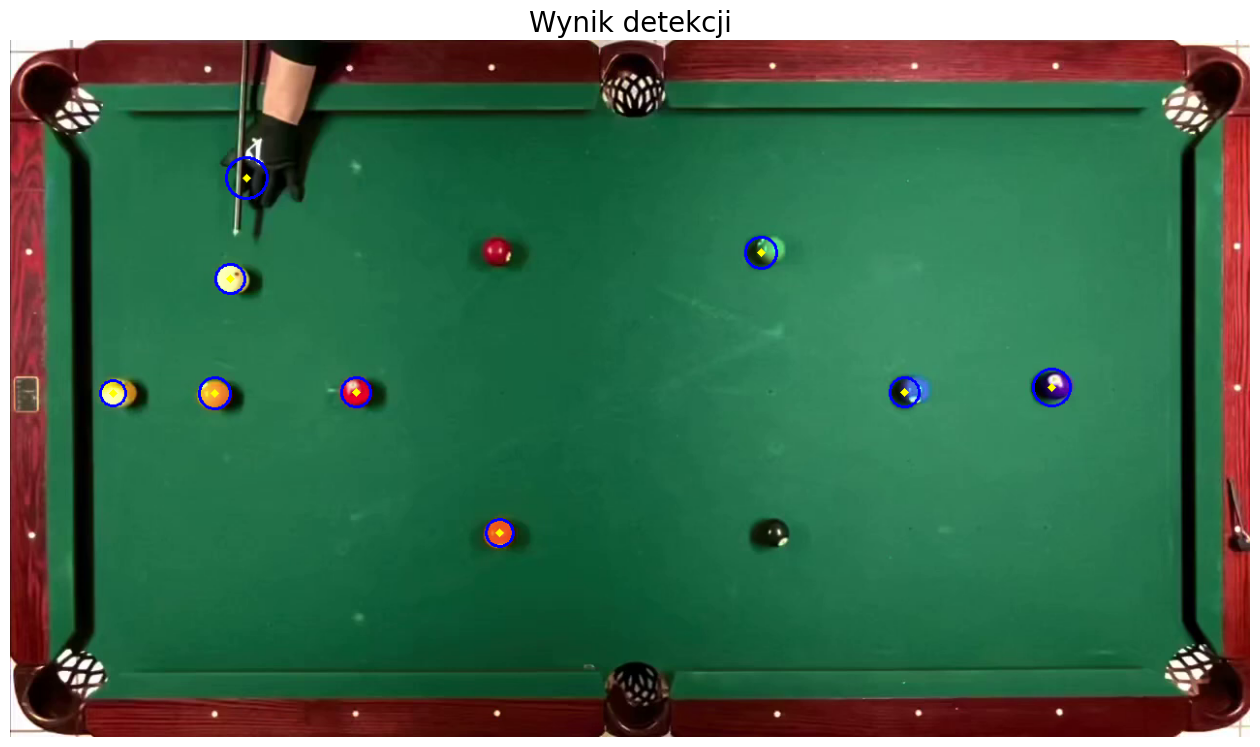

In [5]:
# Maskowanie stołu
masked_img = frame * mask[:, :, np.newaxis]

# Konwersja do HSV i pobranie kanału V
hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
v = hsv[:, :, 2]

# Rozmycie, by ograniczyć szumy
v_blurred = cv2.GaussianBlur(v, (7,7), 1.5)

# Gradient Sobela
grad_x = cv2.Sobel(v_blurred, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(v_blurred, cv2.CV_64F, 0, 1, ksize=3)

grad_magnitude = cv2.magnitude(grad_x, grad_y)
grad_magnitude = np.uint8(np.clip(grad_magnitude, 0, 255))

# Adaptacyjne progowanie gradientu
thresh_grad = cv2.adaptiveThreshold(grad_magnitude, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 11, 2)

# Morphologiczne zamknięcie
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
closed = cv2.morphologyEx(thresh_grad, cv2.MORPH_CLOSE, kernel)

# Znajdź kontury
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def is_circle_like(contour, min_area=150, max_area=3500, solidity_thresh=0.85, circ_thresh=0.65):
    area = cv2.contourArea(contour)
    if area < min_area or area > max_area:
        return False
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return False
    circ = 4 * np.pi * (area / (perimeter * perimeter))
    if circ < circ_thresh:
        return False
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    if hull_area == 0:
        return False
    solidity = float(area) / hull_area
    if solidity < solidity_thresh:
        return False
    return True

circle_like_contours = [c for c in contours if is_circle_like(c)]

output = frame.copy()
for c in circle_like_contours:
    (x, y), radius = cv2.minEnclosingCircle(c)
    center = (int(x), int(y))
    radius = int(radius)
    cv2.circle(output, center, radius, (0, 255, 0), 2)
    cv2.circle(output, center, 2, (0, 0, 255), -1)

# HoughCircles na kanale V
circles = cv2.HoughCircles(v_blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                           param1=50, param2=30, minRadius=10, maxRadius=40)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        cv2.circle(output, (i[0], i[1]), i[2], (255,0,0), 2)
        cv2.circle(output, (i[0], i[1]), 2, (0,255,255), 3)

def show_big_img(title, img, cmap=None):
    plt.figure(figsize=(16, 12))
    plt.imshow(img, cmap=cmap)
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

show_big_img("Masked Image", cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
show_big_img("Kanał V rozmyty", v_blurred, cmap='gray')
show_big_img("Gradient magnitude", grad_magnitude, cmap='gray')
show_big_img("Progowanie adaptacyjne", thresh_grad, cmap='gray')
show_big_img("Morph. Close", closed, cmap='gray')
show_big_img("Wynik detekcji", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))


Postarajmy się może jednak pójść inną drogą z bardziej automatyczną detekcją kulistych kształtów na stole. Niby na przykładzie powyżej nie jest najgorzej, ale jednak wykrywanie ręki gracza jako Bili, albo pomijanie czarnej to nie jest jeszcze najlepszy wynik na jaki nas stać.

Zapraszamy dalej!

To podejście wygląda znacznie czyściej, schludniej, i o dziwo działa też lepiej. Same plusy?
Może.
A to jeszcze nie koniec.

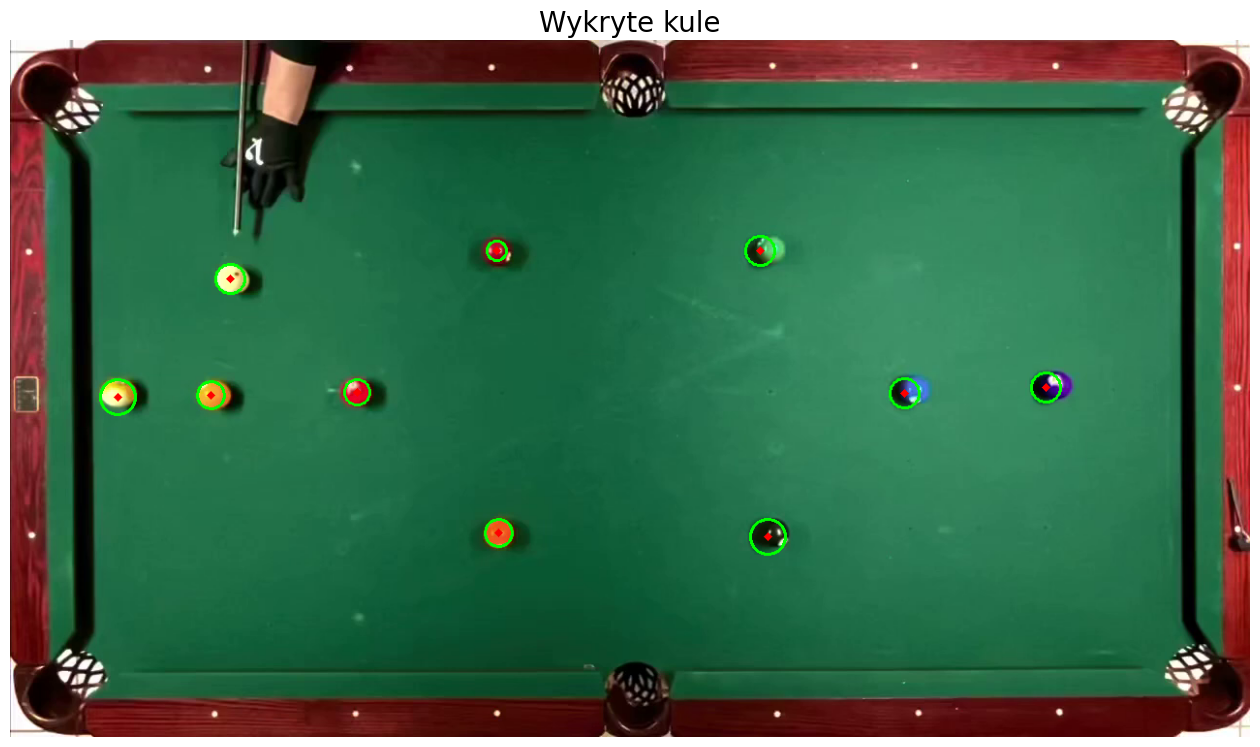

In [6]:
def show_big_img(title, img, cmap=None):
    plt.figure(figsize=(16, 12))
    plt.imshow(img, cmap=cmap)
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

masked_img = frame * mask[:, :, np.newaxis]

# Konwersja do HSV i pobranie kanału V - Value (jasność)
hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
v = hsv[:, :, 2]

# rozmycie
v_blurred = cv2.GaussianBlur(v, (9, 9), 2)

# Wykrywanie kół
circles = cv2.HoughCircles(
    v_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.1,
    minDist=30,
    param1=50,
    param2=25,
    minRadius=10,
    maxRadius=25
)

output = frame.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        center = (i[0], i[1])
        radius = i[2]
        cv2.circle(output, center, radius, (0, 255, 0), 2)
        cv2.circle(output, center, 2, (0, 0, 255), 3)

# Wizualizacja
show_big_img("Wykryte kule", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

In [7]:
import cv2
import numpy as np
import os

# params
video_path = 'snooker_test3.mp4'
output_path = 'snooker_detected3_3.0_output.mp4'
output_fps = 30

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or output_fps

# ustawienia output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

mask = create_table_mask((height, width))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    masked_img = frame * mask[:, :, np.newaxis]

    hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    v_blurred = cv2.GaussianBlur(v, (9, 9), 2)

    circles = cv2.HoughCircles(
        v_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.1,
        minDist=30,
        param1=50,
        param2=25,
        minRadius=10,
        maxRadius=25
    )

    output = frame.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            center = (i[0], i[1])
            radius = i[2]
            cv2.circle(output, center, radius, (0, 255, 0), 2)
            cv2.circle(output, center, 2, (0, 0, 255), 3)

    out.write(output)

    frame_idx += 1
    if frame_idx % 300 == 0:
        print(f"Przetworzono {frame_idx} klatek...") # to tak dla nas, żeby było wiadomo, że jeszcze mieli, a nie że nas rozłączyło z Colaba...

cap.release()
out.release()
print("Zakończono zapisywanie filmu:", output_path)


Przetworzono 300 klatek...
Przetworzono 600 klatek...
Przetworzono 900 klatek...
Przetworzono 1200 klatek...
Przetworzono 1500 klatek...
Przetworzono 1800 klatek...
Przetworzono 2100 klatek...
Przetworzono 2400 klatek...
Przetworzono 2700 klatek...
Zakończono zapisywanie filmu: snooker_detected3_3.0_output.mp4


No i super, w tym momencie mamy już pierwsze obrobione wideo!
Fajnie byłoby np teraz widzieć kolory, albo wbicia tych bil, i dostać coś więcej niż 3.0 za ten projekt, no nie?

...

no to lecimy dalej, przecież już powinno być z górki, prawda?

prawda???

In [8]:
# to tylko takie przypomnienie, albo raczej, ktoś kiedyś zapomniał zmienić u góry...
# HA, HB = (60, 660), (60, 70)
# HE, HF = (650, 670), (650, 70)
# HC, HD = (1215, 650), (1215, 70)
# HOLES = HA, HB, HC, HD, HE, HF

def detect_potted(prev_positions, curr_positions, pocket_coords, events_log, frame_idx, fps, radius_thresh=30, cooldown_s=1.0):
    potted = []
    cooldown_frames = int(fps * cooldown_s)

    for i, pos in enumerate(prev_positions):
        # Sprawdzenie czy ta kula była już wbita w ostatnim czasie (powtarzające się timestampy różnych klatek tego samego wbicia)
        recent_events = [
            e for e in events_log
            if e['event'] == 'potted' and (frame_idx - e['frame']) <= cooldown_frames
            # czasami algorytm uważa, że to różna bila mimo, że jest to ta sama => dla testu usuwamy sprawdzenie, która bila według niego wleciała
            # if e['event'] == 'potted' and (frame_idx - e['frame']) and e['ball'] == i < cooldown_frames
        ]
        if recent_events:
            # Bila była wbita zbyt niedawno, ignoruj
            continue

        found = False
        for cp in curr_positions:
            if np.linalg.norm(np.array(pos) - np.array(cp)) < 15:
                found = True
                break

        if not found:
            for pocket in pocket_coords:
                if np.linalg.norm(np.array(pos) - np.array(pocket)) < radius_thresh:
                    potted.append(i)
                    break
    return potted


def detect_collision(curr_positions, threshold=50):
    collisions = []
    for i, pos1 in enumerate(curr_positions):
        for j, pos2 in enumerate(curr_positions):
            if i >= j:
                continue
            d_now = np.linalg.norm(np.array(pos1) - np.array(pos2))
            if d_now < threshold:
                collisions.append((i, j))
    return collisions

def frame_to_timestamp(frame_idx, fps):
    seconds = frame_idx / fps
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    millis = int((seconds - mins*60 - secs) * 1000)
    return f"{mins:02d}:{secs:02d}.{millis:03d}"


In [9]:
import cv2
import numpy as np
import os
import pandas as pd

events_log = []

video_path = 'snooker_test3.mp4'
output_path = 'snooker_detected3_4.0_output.mp4'
output_fps = 30

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or output_fps

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

mask = create_table_mask((height, width))

prev_positions = None
curr_positions = None
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    masked_img = frame * mask[:, :, np.newaxis]

    hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    v_blurred = cv2.GaussianBlur(v, (9, 9), 2)

    circles = cv2.HoughCircles(
        v_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.1,
        minDist=30,
        param1=50,
        param2=25,
        minRadius=10,
        maxRadius=25
    )

    output = frame.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        tmp = curr_positions.copy() if curr_positions is not None else None
        curr_positions = circles[0]
        prev_positions = tmp if prev_positions is not None else curr_positions.copy()

        for i in curr_positions:
            center = (i[0], i[1])
            radius = i[2]
            cv2.circle(output, center, radius, (0, 255, 0), 2)
            cv2.circle(output, center, 2, (0, 0, 255), 3)
    else:
        prev_positions = curr_positions

    if prev_positions is not None and curr_positions is not None:
        prev_coords = [(x, y) for (x, y, _) in prev_positions]
        curr_coords = [(x, y) for (x, y, _) in curr_positions]

        potted = detect_potted(prev_coords, curr_coords, HOLES, events_log, frame_idx, fps)
        collisions = detect_collision(curr_coords)

        timestamp = frame_to_timestamp(frame_idx, fps)

        if potted:
            print(f"Potted: {potted} @ frame {frame_idx}")
            for i in potted:
                events_log.append({
                    'event': 'potted',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'ball': i
                })

        if collisions:
            print(f"Collisions: {collisions} @ frame {frame_idx}")
            for (i, j) in collisions:
                events_log.append({
                    'event': 'collision',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'balls': (i, j)
                })

    out.write(output)

    frame_idx += 1
    if frame_idx % 300 == 0:
        print(f"Przetworzono {frame_idx} klatek...")

cap.release()
out.release()

df = pd.DataFrame(events_log)
df.to_csv('billiard_events.csv', index=False)

print("Zakończono zapisywanie filmu:", output_path)
print("Zapisano zdarzenia do billiard_events.csv")


Potted: [9] @ frame 233
Przetworzono 300 klatek...
Przetworzono 600 klatek...
Collisions: [(0, 4)] @ frame 850
Collisions: [(0, 5)] @ frame 851
Collisions: [(1, 5)] @ frame 852
Collisions: [(2, 5)] @ frame 853
Collisions: [(4, 5)] @ frame 854
Collisions: [(1, 5)] @ frame 855
Collisions: [(2, 5)] @ frame 856
Collisions: [(0, 4)] @ frame 857
Collisions: [(0, 4)] @ frame 858
Collisions: [(0, 5)] @ frame 859
Collisions: [(0, 4)] @ frame 860
Collisions: [(0, 5)] @ frame 861
Collisions: [(0, 4)] @ frame 863
Collisions: [(0, 5)] @ frame 864
Collisions: [(1, 4)] @ frame 867
Collisions: [(0, 4)] @ frame 868
Collisions: [(0, 4)] @ frame 869
Przetworzono 900 klatek...
Collisions: [(3, 5)] @ frame 1068
Potted: [2] @ frame 1095
Przetworzono 1200 klatek...
Potted: [4] @ frame 1386
Przetworzono 1500 klatek...
Potted: [3] @ frame 1657
Przetworzono 1800 klatek...
Collisions: [(0, 3)] @ frame 1917
Przetworzono 2100 klatek...
Przetworzono 2400 klatek...
Collisions: [(0, 1)] @ frame 2517
Przetworzono 2700

Nie działa idealnie. Bile czasmi wlatują zbyt dynamicznie przez co odległość nie jest zachowana za kształt zniekształcany na klatce. Dodatkowo przy przesuwaniu się gracza dodatkowe "bile" (kształty kuliste) się pojawiają przez co np. w 7.766 sekundzie obserwujemy pojawienie się wyimaginowanie kuli w środku łuzy co skutkuje zapisaniem o trafieniu. Zmieńmy trochę kocept zapiszmy ich kolory i handlujmy znikanie danych kolorów.

In [10]:
def detect_potted(prev_positions, curr_positions, pocket_coords, events_log, frame_idx, fps, radius_thresh=40, cooldown_s=1.0):
    potted = []
    cooldown_frames = int(fps * cooldown_s)

    for i, pos in enumerate(prev_positions):
        recent = [
            e for e in events_log
            if e['event'] == 'potted' and (frame_idx - e['frame']) <= cooldown_frames #and e['ball'] == i
        ]
        if recent:
            continue

        found = False
        for cp in curr_positions:
            if np.linalg.norm(np.array(pos) - np.array(cp)) < 15:
                found = True
                break

        if not found:
            for pocket in pocket_coords:
                if np.linalg.norm(np.array(pos[:2]) - np.array(pocket)) < radius_thresh:
                    potted.append(i)
                    break
    return potted


def detect_collision(curr_positions, factor=1.375, debug=False):
    collisions = []
    for i in range(len(curr_positions)):
        x1, y1, r1 = [int(v) for v in curr_positions[i]]
        for j in range(i + 1, len(curr_positions)):
            x2, y2, r2 = [int(v) for v in curr_positions[j]]
            dist = np.hypot(x1 - x2, y1 - y2)
            threshold = factor * (r1 + r2)
            if debug:
                print(f"Distance between {i}, {j} = {dist:.2f} (threshold: {threshold:.2f})")
            if dist < threshold:
                collisions.append((i, j))
    return collisions


events_log = []

video_path = 'snooker_test3.mp4'
output_path = 'snooker_detected3_4.0_output.mp4'
output_fps = 30

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or output_fps

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

mask = create_table_mask((height, width))

prev_positions = None
curr_positions = None
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    masked_img = frame * mask[:, :, np.newaxis]

    hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    v_blurred = cv2.GaussianBlur(v, (9, 9), 2)

    circles = cv2.HoughCircles(
        v_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=25,
        param1=50,
        param2=25,
        minRadius=10,
        maxRadius=23
    )

    output = frame.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        tmp = curr_positions.copy() if curr_positions is not None else None
        curr_positions = circles[0]
        prev_positions = tmp if prev_positions is not None else curr_positions.copy()

        for i in curr_positions:
            center = (i[0], i[1])
            radius = i[2]
            cv2.circle(output, center, radius, (0, 255, 0), 2)
            cv2.circle(output, center, 2, (0, 0, 255), 3)
    else:
        prev_positions = curr_positions

    if prev_positions is not None and curr_positions is not None:
        prev_coords = [(x, y, r) for (x, y, r) in prev_positions]
        curr_coords = [(x, y, r) for (x, y, r) in curr_positions]

        potted = detect_potted(prev_coords, curr_coords, HOLES, events_log, frame_idx, fps)
        collisions = detect_collision(curr_coords)

        timestamp = frame_to_timestamp(frame_idx, fps)

        if potted:
            print(f"Potted: {potted} @ frame {frame_idx} @ timestamp {timestamp}")
            for i in potted:
                events_log.append({
                    'event': 'potted',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'ball': i
                })

        if collisions:
            print(f"Collisions: {collisions} @ frame {frame_idx} @ timestamp {timestamp}")
            for (i, j) in collisions:
                events_log.append({
                    'event': 'collision',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'balls': (i, j)
                })

    out.write(output)

    frame_idx += 1
    if frame_idx % 300 == 0:
        print(f"Przetworzono {frame_idx} klatek...")

cap.release()
out.release()

df = pd.DataFrame(events_log)
df.to_csv('billiard_events.csv', index=False)

print("Zakończono zapisywanie filmu:", output_path)
print("Zapisano zdarzenia do billiard_events.csv")


Collisions: [(5, 7)] @ frame 129 @ timestamp 00:04.299
Potted: [8] @ frame 148 @ timestamp 00:04.933
Collisions: [(7, 9)] @ frame 198 @ timestamp 00:06.599
Collisions: [(6, 9)] @ frame 205 @ timestamp 00:06.833
Potted: [9] @ frame 220 @ timestamp 00:07.333
Przetworzono 300 klatek...
Collisions: [(3, 7)] @ frame 381 @ timestamp 00:12.699
Przetworzono 600 klatek...
Potted: [7] @ frame 730 @ timestamp 00:24.333
Collisions: [(1, 4)] @ frame 865 @ timestamp 00:28.833
Przetworzono 900 klatek...
Potted: [6] @ frame 962 @ timestamp 00:32.066
Collisions: [(1, 4)] @ frame 1066 @ timestamp 00:35.533
Collisions: [(3, 4)] @ frame 1067 @ timestamp 00:35.566
Potted: [1] @ frame 1094 @ timestamp 00:36.466
Przetworzono 1200 klatek...
Potted: [0] @ frame 1383 @ timestamp 00:46.100
Przetworzono 1500 klatek...
Potted: [4] @ frame 1655 @ timestamp 00:55.166
Przetworzono 1800 klatek...
Potted: [3] @ frame 1953 @ timestamp 01:05.099
Przetworzono 2100 klatek...
Potted: [2] @ frame 2300 @ timestamp 01:16.666
P

Są plusy. Poprawnie znaleźliśmy aż 9 z 10 trafień. (być może gdyby było więcej czasu to jest kwestia *tweaku* parametrów wykrywania kulistych kształów - jest to jednak prawie zawsze coś za coś, wykrycie jednego zdarzania więcej, ale też przy okazji 10 takich, których nie chcesz wykrywać i vice versa). Niestety przez gracza, który porusza się i zwiększenie progu $dp$ dla wykrywania okręgów, wykrywamy czasami przebłyski w łuzach przez ruchy gracza. Przez to 2 razy wykryliśmy coś jako ,,potted'', mimo iż było to po prostu nagłe poruszenie gracza i zmiana koloru przez prześwitujące łuzy. Czasami kula jest wykrywana przez kilka klatek w łuzie stąd duplikaty, ale to kwestia tylko czysto wyczyszczenia duplikatów i trackowania pozycji kul oraz ich id.

Podobna sprawa ma się do kolizji, wielokrotne powtórzenia kolizji w niewielkim odstępie czasowym, ale nie jest to wielki problem.

Problematycznym jest zachowanie proporcji do prędkości. Jest to problematyczne, ponieważ szybkie uderzenia mogą być niewykrywalne jako kolizje (szybki ruch białej bili) a także ich wynik - szybkie wpadnięcie do łuzy, może być pominięte. Większość takich detekcji jednak się zgadza z założeniami. Dlatego też, czasami widoczne jest zachowanie typu była kolizja, ale bez wbicia bili lub bila została wbita, ale nie wiadomo kiedy wcześniej nadeszła kolizja, która to spowodowała. Jest to kwestia prędkości uderzenia i factor'u jak bardzo respektujemy odległości między klatkami.

In [11]:
def detect_potted(prev_positions, curr_positions, pocket_coords, events_log, frame_idx, fps, radius_thresh=40, cooldown_s=1.0):
    potted = []
    cooldown_frames = int(fps * cooldown_s)

    for i, pos in enumerate(prev_positions):
        recent = [
            e for e in events_log
            if e['event'] == 'potted' and (frame_idx - e['frame']) <= cooldown_frames #and e['ball'] == i
        ]
        if recent:
            continue

        found = False
        for cp in curr_positions:
            if np.linalg.norm(np.array(pos) - np.array(cp)) < 15:
                found = True
                break

        if not found:
            for pocket in pocket_coords:
                if np.linalg.norm(np.array(pos[:2]) - np.array(pocket)) < radius_thresh:
                    potted.append(i)
                    break
    return potted


def detect_collision(curr_positions, factor=1.375, debug=False):
    collisions = []
    for i in range(len(curr_positions)):
        x1, y1, r1 = [int(v) for v in curr_positions[i]]
        for j in range(i + 1, len(curr_positions)):
            x2, y2, r2 = [int(v) for v in curr_positions[j]]
            dist = np.hypot(x1 - x2, y1 - y2)
            threshold = factor * (r1 + r2)
            if debug:
                print(f"Distance between {i}, {j} = {dist:.2f} (threshold: {threshold:.2f})")
            if dist < threshold:
                collisions.append((i, j))
    return collisions

BALL_SCORES = {
    'white': 0,
    'yellow': 1,
    'orange': 2,
    'red': 3,
    'bordo': 4,
    'green': 5,
    'blue': 6,
    'purple': 7,
    'black': 8
}

# tweak kolorków needed
def classify_ball_color(bgr_color):
    hsv_color = cv2.cvtColor(np.uint8([[bgr_color]]), cv2.COLOR_BGR2HSV)[0][0]
    h, s, v = hsv_color

    if s < 50 and v > 180:
        return 'white'
    if v < 50:
        return 'black'
    if 10 <= h < 20:
        return 'orange'
    if 20 <= h < 30:
        return 'yellow'
    if 0 <= h < 10 or h >= 170:
        return 'red'
    if 160 <= h < 170:
        return 'bordo'
    if 35 <= h < 85:
        return 'green'
    if 85 <= h < 130:
        return 'blue'
    if 130 <= h < 160:
        return 'purple'

    return 'unknown'

ball_colors = {}
score = 0
score_points_potted = []

events_log = []

video_path = 'snooker_test3.mp4'
output_path = 'snooker_detected3_5.0_output.mp4'
output_fps = 30

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or output_fps

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

mask = create_table_mask((height, width))

prev_positions = None
curr_positions = None
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    masked_img = frame * mask[:, :, np.newaxis]

    hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    v_blurred = cv2.GaussianBlur(v, (9, 9), 2)

    circles = cv2.HoughCircles(
        v_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=25,
        param1=50,
        param2=25,
        minRadius=10,
        maxRadius=23
    )

    output = frame.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        tmp = curr_positions.copy() if curr_positions is not None else None
        curr_positions = circles[0]
        prev_positions = tmp if prev_positions is not None else curr_positions.copy()

        ball_colors = {}
        for idx, i in enumerate(curr_positions):
            x, y, r = map(int, i)
            roi = frame[max(y-2,0):y+3, max(x-2,0):x+3]
            if roi.size > 0:
                mean_color = tuple(np.mean(roi.reshape(-1, 3), axis=0).astype(np.uint8))
                color_label = classify_ball_color(mean_color)
            else:
                color_label = 'unknown'
            ball_colors[idx] = color_label

            center = (x, y)
            cv2.circle(output, center, r, (0, 255, 0), 2)
            cv2.circle(output, center, 2, (0, 0, 255), 3)
            cv2.putText(output, color_label, (x - 10, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

        for i in curr_positions:
            center = (i[0], i[1])
            radius = i[2]
            cv2.circle(output, center, radius, (0, 255, 0), 2)
            cv2.circle(output, center, 2, (0, 0, 255), 3)
    else:
        prev_positions = curr_positions

    if prev_positions is not None and curr_positions is not None:
        prev_coords = [(x, y, r) for (x, y, r) in prev_positions]
        curr_coords = [(x, y, r) for (x, y, r) in curr_positions]

        potted = detect_potted(prev_coords, curr_coords, HOLES, events_log, frame_idx, fps)
        collisions = detect_collision(curr_coords)

        timestamp = frame_to_timestamp(frame_idx, fps)

        if potted:
            print(f"Potted: {potted} @ frame {frame_idx} @ timestamp {timestamp}")
            for i in potted:
                color = ball_colors.get(i, 'unknown')
                points = BALL_SCORES.get(color, 0)
                score_points_potted.append((color, points))
                score += points
                print(f"  Ball {i} ({color}) scored {points} point(s). Total: {score}")
                events_log.append({
                    'event': 'potted',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'ball': i,
                    'color': color,
                    'points': points,
                    'score': score
                })

        if collisions:
            print(f"Collisions: {collisions} @ frame {frame_idx} @ timestamp {timestamp}")
            for (i, j) in collisions:
                events_log.append({
                    'event': 'collision',
                    'frame': frame_idx,
                    'timestamp': timestamp,
                    'balls': (i, j)
                })

    out.write(output)

    frame_idx += 1
    if frame_idx % 300 == 0:
        print(f"Przetworzono {frame_idx} klatek...")

cap.release()
out.release()

df = pd.DataFrame(events_log)
df.to_csv('billiard_events.csv', index=False)

print("Zakończono zapisywanie filmu:", output_path)
print("Zapisano zdarzenia do billiard_events.csv")
print(f"Score: {score}\nPoint after point: {score_points_potted}")


Collisions: [(5, 7)] @ frame 129 @ timestamp 00:04.299
Potted: [8] @ frame 148 @ timestamp 00:04.933
  Ball 8 (black) scored 8 point(s). Total: 8
Collisions: [(7, 9)] @ frame 198 @ timestamp 00:06.599
Collisions: [(6, 9)] @ frame 205 @ timestamp 00:06.833
Potted: [9] @ frame 220 @ timestamp 00:07.333
  Ball 9 (purple) scored 7 point(s). Total: 15
Przetworzono 300 klatek...
Collisions: [(3, 7)] @ frame 381 @ timestamp 00:12.699
Przetworzono 600 klatek...
Potted: [7] @ frame 730 @ timestamp 00:24.333
  Ball 7 (unknown) scored 0 point(s). Total: 15
Collisions: [(1, 4)] @ frame 865 @ timestamp 00:28.833
Przetworzono 900 klatek...
Potted: [6] @ frame 962 @ timestamp 00:32.066
  Ball 6 (green) scored 5 point(s). Total: 20
Collisions: [(1, 4)] @ frame 1066 @ timestamp 00:35.533
Collisions: [(3, 4)] @ frame 1067 @ timestamp 00:35.566
Potted: [1] @ frame 1094 @ timestamp 00:36.466
  Ball 1 (yellow) scored 1 point(s). Total: 21
Przetworzono 1200 klatek...
Potted: [0] @ frame 1383 @ timestamp 00:

Handlowanie punktacji było dość eksperymentalne. Po prostu dane kolory jakoś wyceniliśmy. Jeżeli kolor na klatce, nie został rozpoznany (przy znanej (jak wyżej minimalnie wadliwej) bili wpadającej do łuny) to było przypisane 0 punktów, ale bila per se była rozpatrzona. Problematycznym naturalnie jest nierozpoznawanie bili, lecz również jej koloru. Funkcja detekcji nie jest idealna i bierze pod uwagę klatkę, w której był wrzut. Dodatkowo jeżeli parametry między prędkością uderzenia a czasem reakcji i odległości wykrywania kolizji i wpadnięcia generują problemy, że niekiedy można było naliczyć podwójne punkty (co prawda akurat nie udało nam się tego osiągnąć, ponieważ za pierwszym razem wykrywał dobry kolor, a w następnej już niezdefiniowany, ale de facto istnieje taka możliwość).

Próbowałem nawet wersję z napisaniem sieci neuronowej do predykcji koloru based on wejściowe piksele, ale wyniki były mierne. Tweakowanie kolorów jest tutaj bardzo koniecznie, niestety często zdarza się *unknown*.

~~ Nie no, sieć neuronowa tutaj to bez sensu raczej, myślę że lepiej ten if elif co jest - dop. produkcyjny~~

Dodatkowo to co wcześniej było, czyli poruszanie gracza czasami skutkuje pojawieniem się wykrytego kulistego obszaru w okolicy łuzy co czasami skutkuje np. tym, że algorytm uważa, że wbiliśmy powiedzmy fioletową bilę do łuzy mimo iż na stole taka sytuacja nie miała miejsca - i oczywiście dolicza sobie za to punkty.

# Może nie najlepiej, ale jako-tako

No i to by było na tyle z tej krótkiej podróży.
Mamy nadzieje że się podobało.

Miłego dnia i smacznej kawusi :)




